# Chromatin PTR analysis
March 18, 2024

Simple PTR analysis to compare deconvolved PTR to raw PTR.

Then compare deconvolved PTR to gene expression deconvovled PTR.


In [48]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
import glob

outdir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(outdir)


## Evaluating different metrics to summarize gene PTR's

Next, we will evaluate other metrics that can capture a larger summary of the PTR image per gene. 

Metrics:
- Mean
- Median
- Quantiles: 80, 20

Evaluation:
- Plot a set of 20 genes and their PTR images, and evaluate how each metric measures up per gene.


In [50]:
peak_to_trough_analysis.compute_summary_metrics()

In [63]:
peak_to_trough_analysis.load_Fourier_scores()

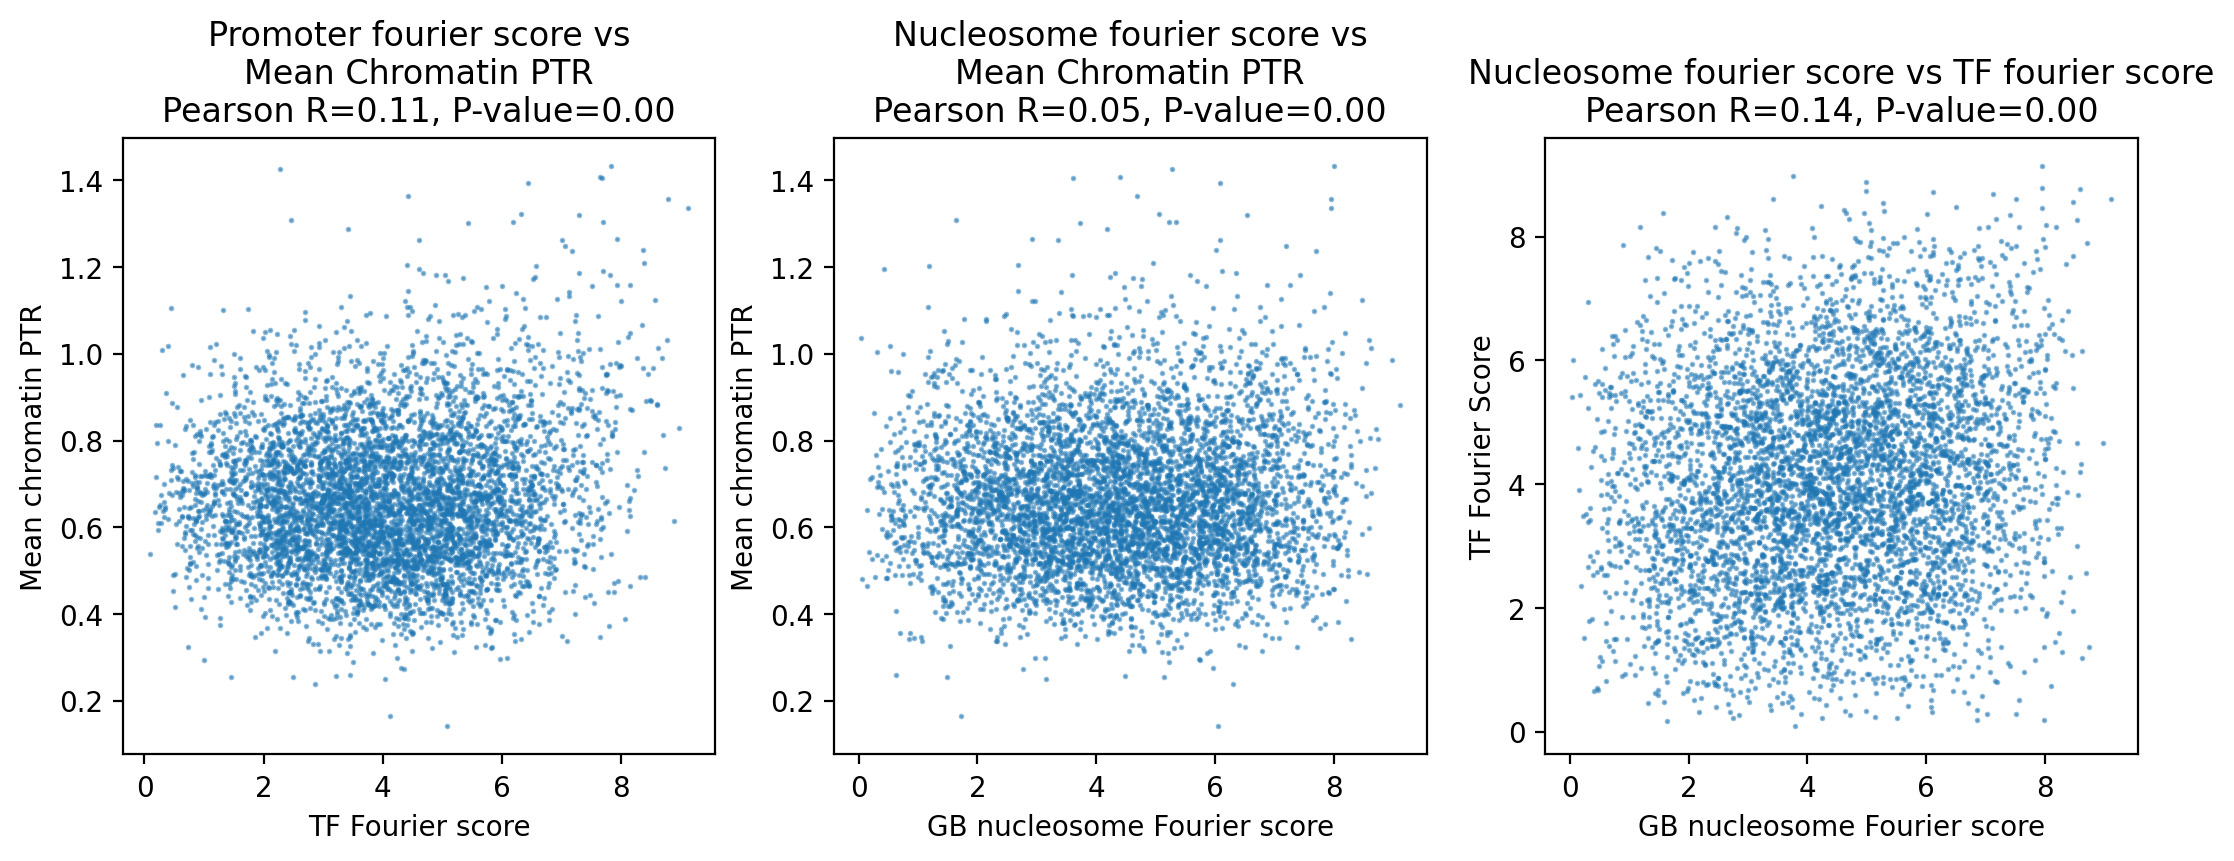

In [66]:
peak_to_trough_analysis.plot_ptr_comparison_to_fourier()

In [152]:
from src.config import load_yl_rg1_vst_config
from cc_src.chromatin_model import ChromatinModel

def compute_g_ptr(gene_name, replicate):
    config1 = load_yl_rg1_vst_config(replicate)

    chromatin_model1 = ChromatinModel(config1)
    chromatin_model1.load_mnase_gene(gene_name, log=False)
    chromatin_model1.create_deconvolution_bins()

    # Compute the raw PTR for the gene for both replicates
    from cc_src.peak_to_trough import compute_quantile_ptr

    mu0 = config1.intervals_wt1[0][0]

    # Compute the peak to trough ratio for non recovery timepoints
    non_RG1_G = chromatin_model1.G[chromatin_model1.timepoints > mu0, :]
    g_ptrs = np.apply_along_axis(lambda mat: compute_quantile_ptr(mat, 
        0.2, 0.8), 0, non_RG1_G)
    return g_ptrs


In [169]:
from src.timer import Timer
from cc_src.reference_data import load_analysis_genes

def get_g_ptrs_replicate(replicate):
    timer = Timer()
    
    geneset = load_analysis_genes()
    g_ptrs_df = None

    i = 0
    for orf_name, gene in geneset.iterrows():
        current_g_ptrs = compute_g_ptr(orf_name, replicate)

        if g_ptrs_df is None:        
            g_ptrs_df = pd.DataFrame(index=geneset.index.values,
                columns=np.arange(current_g_ptrs.shape[0]))

        g_ptrs_df.loc[orf_name, :] = current_g_ptrs

        if i % 100 == 0:
            print(f"{i}/{len(geneset)} - {timer.get_time()}")

        i += 1

    return g_ptrs_df


In [170]:
g_ptrs_1_df = get_g_ptrs_replicate(1)

0/5578 - 00:00:01.57
100/5578 - 00:03:22.70
200/5578 - 00:11:48.53
300/5578 - 00:20:16.14
400/5578 - 00:28:43.62
500/5578 - 00:35:47.32
600/5578 - 00:39:17.63
700/5578 - 00:52:18.20
800/5578 - 01:07:47.48
900/5578 - 01:23:22.21
1000/5578 - 01:38:54.51
1100/5578 - 01:54:18.27
1200/5578 - 02:09:42.94
1300/5578 - 02:25:10.57
1400/5578 - 02:35:22.63
1500/5578 - 02:41:37.05
1600/5578 - 02:47:51.04
1700/5578 - 02:51:02.53
1800/5578 - 03:00:26.51
1900/5578 - 03:11:19.79
2000/5578 - 03:22:11.35
2100/5578 - 03:33:10.13
2200/5578 - 03:44:21.66
2300/5578 - 03:51:25.46
2400/5578 - 03:57:05.70
2500/5578 - 04:02:38.85
2600/5578 - 04:07:09.48
2700/5578 - 04:12:10.05
2800/5578 - 04:19:33.71
2900/5578 - 04:26:57.43
3000/5578 - 04:34:21.25
3100/5578 - 04:41:29.40
3200/5578 - 04:48:27.94
3300/5578 - 04:55:26.13
3400/5578 - 05:06:56.19
3500/5578 - 05:20:34.83
3600/5578 - 05:34:13.40
3700/5578 - 05:47:47.49
3800/5578 - 06:01:23.09
3900/5578 - 06:10:44.98
4000/5578 - 06:20:01.28
4100/5578 - 06:29:16.75
4200

In [171]:
g_ptrs_1_df.to_csv('output/raw_g_ptrs/g_ptrs_chromatin_rep1.csv')

In [ ]:
g_ptrs_2_df = get_g_ptrs_replicate(2)

0/5578 - 00:00:01.79
100/5578 - 00:03:40.68
200/5578 - 00:13:11.69
300/5578 - 00:22:41.38
400/5578 - 00:32:11.93
500/5578 - 00:40:10.07
600/5578 - 00:43:55.40
700/5578 - 00:59:40.19
800/5578 - 01:18:08.59
900/5578 - 01:36:09.51
1000/5578 - 01:55:00.68
1100/5578 - 02:14:02.25
1200/5578 - 02:32:52.83
1300/5578 - 02:51:58.67
1400/5578 - 03:03:42.16
1500/5578 - 03:10:22.67
1600/5578 - 03:17:11.56
1700/5578 - 03:20:36.43
1800/5578 - 03:31:21.05
1900/5578 - 03:43:49.90
2000/5578 - 03:56:17.35
2100/5578 - 04:08:44.56
2200/5578 - 04:21:16.25
2300/5578 - 04:29:11.33
2400/5578 - 04:35:28.29
2500/5578 - 04:41:39.70
2600/5578 - 04:46:37.05
2700/5578 - 04:52:13.02
2800/5578 - 05:00:54.73
2900/5578 - 05:09:37.23
3000/5578 - 05:18:16.37
3100/5578 - 05:26:35.46
3200/5578 - 05:34:46.65
3300/5578 - 05:43:01.27
3400/5578 - 05:57:04.05
3500/5578 - 06:12:26.31
3600/5578 - 06:27:20.71
3700/5578 - 06:42:10.15
3800/5578 - 06:56:54.11
3900/5578 - 07:07:40.52
4000/5578 - 07:18:42.51


In [ ]:
g_ptrs_2_df.to_csv('output/raw_g_ptrs/g_ptrs_chromatin_rep2.csv')

In [177]:
g_ptr_means_rep1 = g_ptrs_1_df.mean(axis=1)
metrics_df = peak_to_trough_analysis.metrics_df.copy()

metrics_df['mean_g_rep1'] = g_ptr_means_rep1

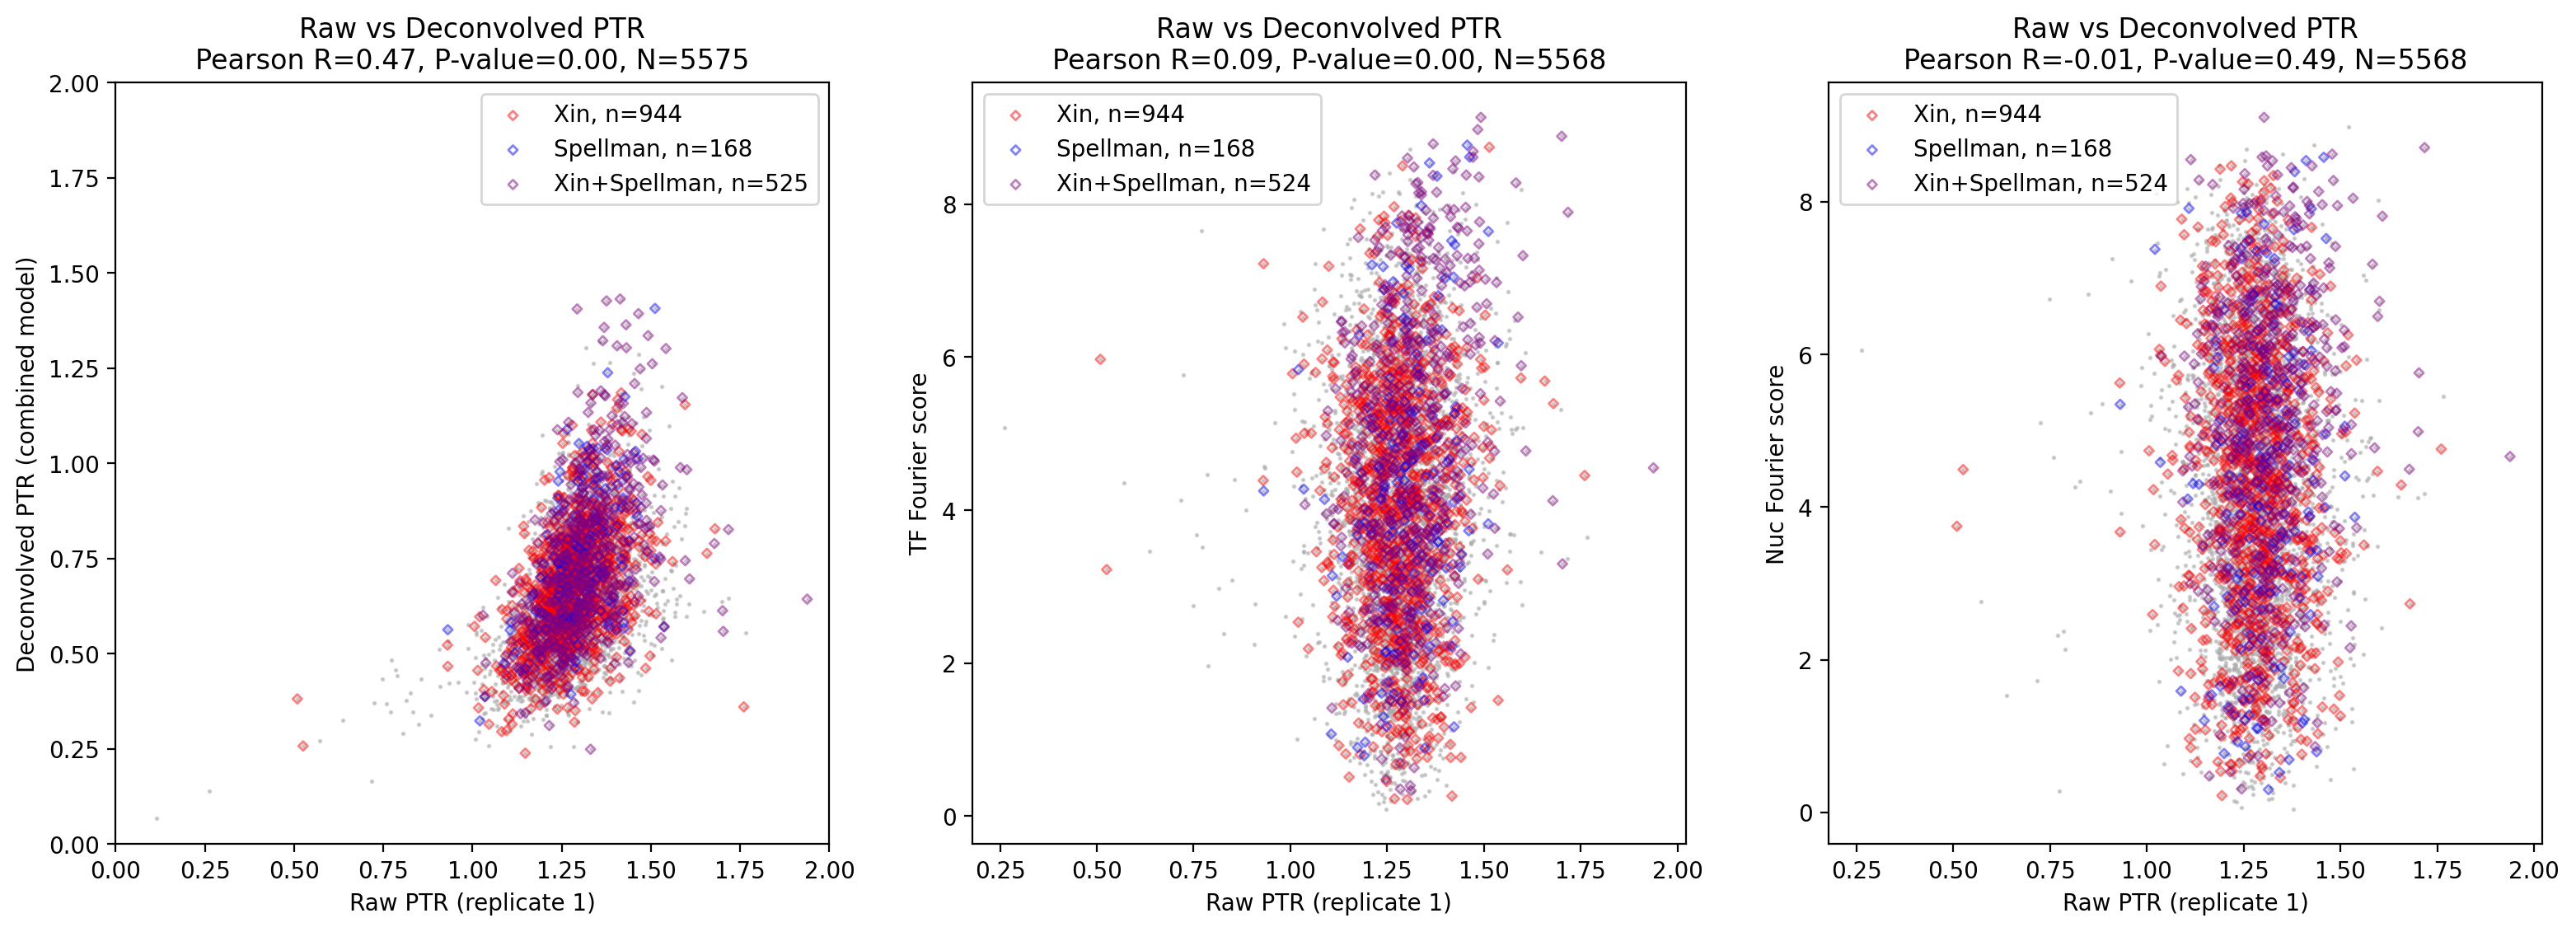

In [243]:
from cc_src.peak_to_trough_anaysis import plot_comparison_scatter, filter_index
from cc_src.reference_data import load_xin_1500_cc_orfs, load_spellman_orfs

xin_orfs = load_xin_1500_cc_orfs()
spellman_orfs = load_spellman_orfs()

both_xin_spellman = set(xin_orfs).intersection(spellman_orfs)
xin_only = set(xin_orfs).difference(both_xin_spellman)
spellman_only = set(spellman_orfs).difference(both_xin_spellman)
    
# Filter the highlighted orfs by the orfs we *do* have for deconvolved
# PTR means
filtered_both_xin_spellman = filter_index(both_xin_spellman, metrics_df.index.values)
filtered_both_xin = filter_index(xin_only, metrics_df.index.values)
filtered_both_spellman = filter_index(spellman_only, metrics_df.index.values)

plt.figure(figsize=(19, 6))
plt.subplot(1, 3, 1)
plot_comparison_scatter(metrics_df['mean_g_rep1'], metrics_df['mean_ptr'], 
                        "Raw vs Deconvolved PTR", "Raw PTR (replicate 1)", 
                        "Deconvolved PTR (combined model)",
                       highlighted_orfs=[
                          (filtered_both_xin, 'red', "Xin"),
                          (filtered_both_spellman, 'blue', "Spellman"),
                          (filtered_both_xin_spellman, 'purple', "Xin+Spellman"),
                       ])
plt.xlim(0, 2)
plt.ylim(0, 2)

plt.subplot(1, 3, 2)

# Filter the highlighted orfs by the fourier analysis set of gene orfs
filtered_both_xin_spellman = filter_index(both_xin_spellman, tf_fourier_compare.index.values)
filtered_both_xin = filter_index(xin_only, tf_fourier_compare.index.values)
filtered_both_spellman = filter_index(spellman_only, tf_fourier_compare.index.values)

tf_fourier_compare = peak_to_trough_analysis.tf_joined_df.copy()
tf_fourier_compare['mean_g_rep1'] = g_ptr_means_rep1
plot_comparison_scatter(tf_fourier_compare['mean_g_rep1'], 
                        tf_fourier_compare['Fourier_score'], 
                        "Raw vs Deconvolved PTR", "Raw PTR (replicate 1)", 
                        "TF Fourier score",
                        highlighted_orfs=[
                          (filtered_both_xin, 'red', "Xin"),
                          (filtered_both_spellman, 'blue', "Spellman"),
                          (filtered_both_xin_spellman, 'purple', "Xin+Spellman"),
                       ])

plt.subplot(1, 3, 3)
nuc_fourier_compare = peak_to_trough_analysis.nuc_joined_df.copy()
nuc_fourier_compare['mean_g_rep1'] = g_ptr_means_rep1
plot_comparison_scatter(nuc_fourier_compare['mean_g_rep1'], 
                        nuc_fourier_compare['Fourier_score'],
                        "Raw vs Deconvolved PTR", "Raw PTR (replicate 1)", 
                        "Nuc Fourier score", 
                       highlighted_orfs=[
                          (filtered_both_xin, 'red', "Xin"),
                          (filtered_both_spellman, 'blue', "Spellman"),
                          (filtered_both_xin_spellman, 'purple', "Xin+Spellman"),
                       ])


In [244]:
# Let's zoom into the raw vs deconvolved ptr plot and create the marginal distributions, we 
# would like to see how the individual subsets line up

In [328]:
from cc_src.peak_to_trough_anaysis import plot_comparison_ptr, create_highlighted_orfs_array

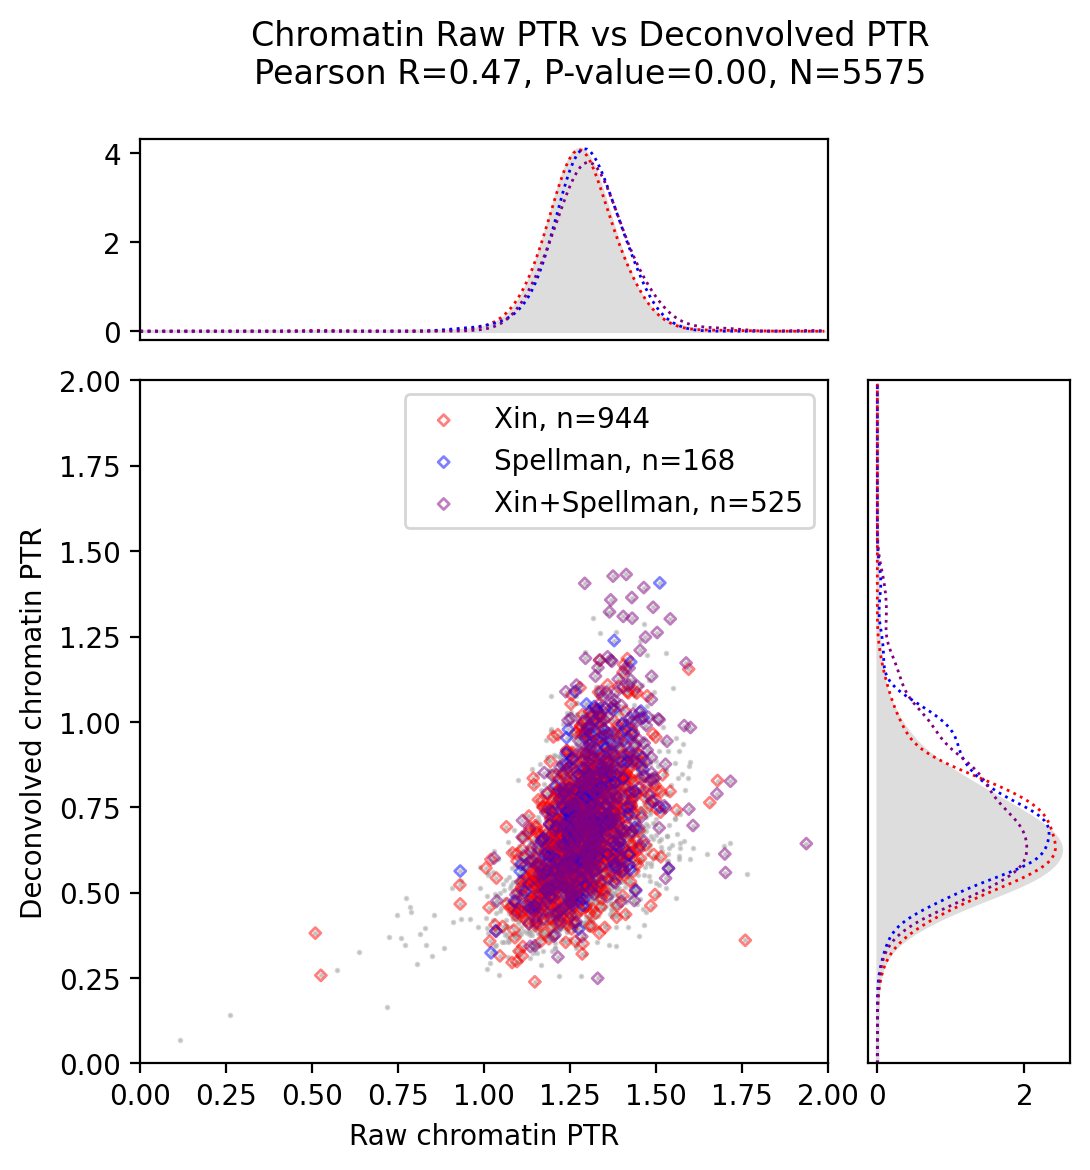

In [332]:

x, y = metrics_df['mean_g_rep1'], metrics_df['mean_ptr']

highlighted_orfs = create_highlighted_orfs_array(metrics_df)

plot_comparison_ptr(x, y, highlighted_orfs, xlim=(0, 2), ylim=(0, 2), 
                    title="Chromatin Raw PTR vs Deconvolved PTR",
                   xlabel="Raw chromatin PTR",
                   ylabel="Deconvolved chromatin PTR")

In [333]:
from cc_src.peak_to_trough_anaysis import load_deconvolved_ge_ptrs

outdir = 'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/'

deconvolved_ge_ptrs = load_deconvolved_ge_ptrs(outdir)

In [334]:
deconvolved_ge_ptrs


,gene,ptr
orf_name,,
YAL067W-A,YAL067W-A,1.0021
YAL067C,SEO1,1.8564
YAL064C-A,YAL064C-A,1.0013
YAL064W,YAL064W,1.0018
YAL063C-A,YAL063C-A,1.002
...,...,...
YPR198W,SGE1,1.0037
YPR199C,ARR1,1.0093
YPR200C,ARR2,1.0546


In [339]:
# Now, compare gene expression and chromatin PTR values, in the perfect case,
# all of the cell cycle genes will be in the top right quadrant. And the data will be a 1:1 line
# However, we know that the chromatin and gene expression do not correlate perfectly
# And there are many cell cycle genes that do no cycle their chromatin, genes without cycling
# expression, but cycling chromatin. And, we expect portions of the chromatin window
# to not be as cycling as others.


In [343]:
ge_chromatin_ptr_df = deconvolved_ge_ptrs.join(metrics_df[['mean_ptr']]).rename(
    columns={'ptr': 'gene_expression_ptr',
            'mean_ptr': 'chromatin_ptr'})
ge_chromatin_ptr_df = ge_chromatin_ptr_df.dropna()
ge_chromatin_ptr_df.head(2)

,gene,gene_expression_ptr,chromatin_ptr
orf_name,,,
YAL067W-A,YAL067W-A,1.0021,0.347143
YAL067C,SEO1,1.8564,0.909288


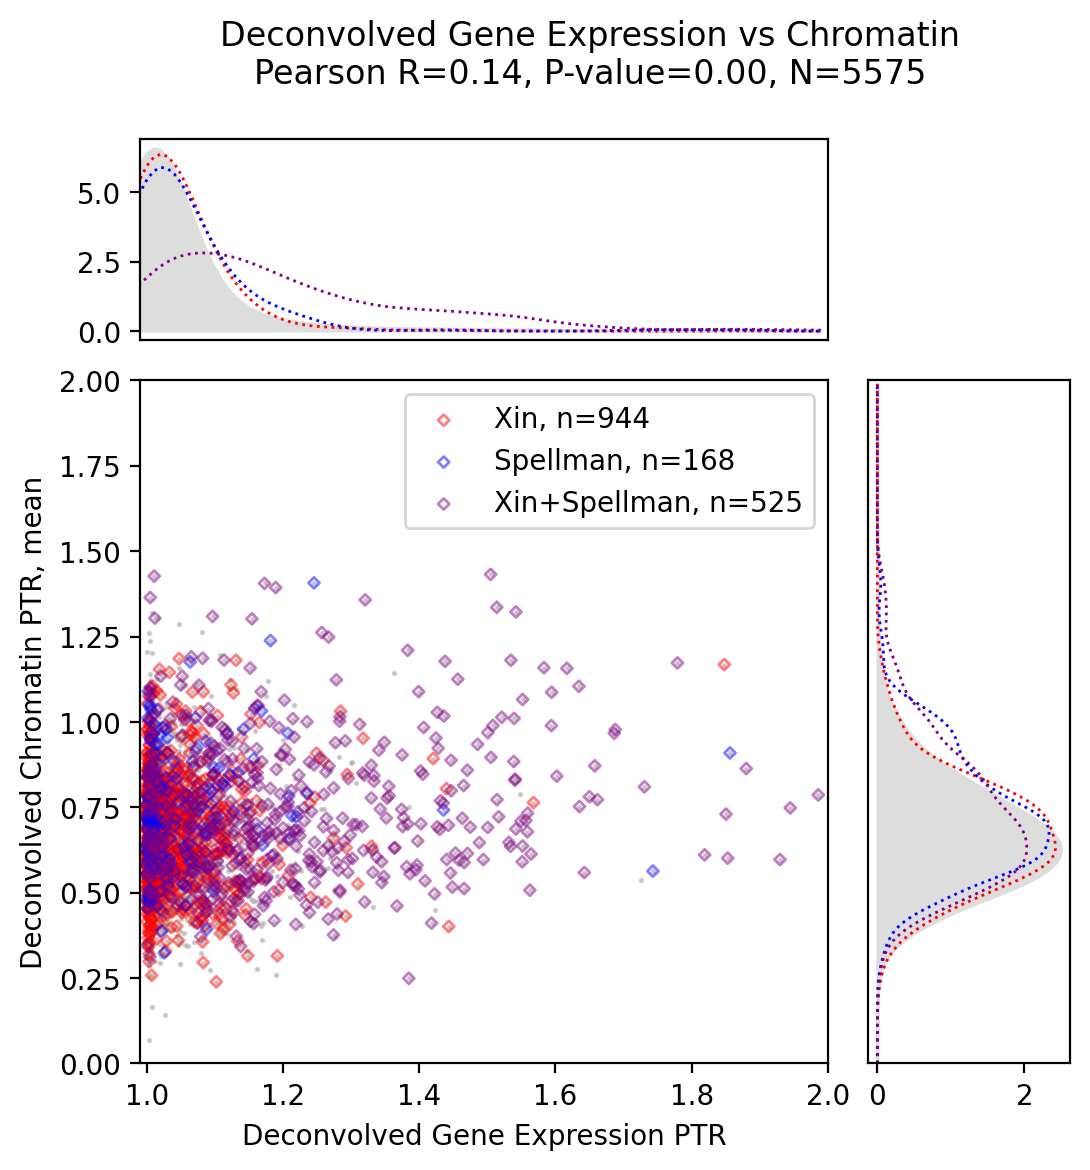

In [350]:

x, y = ge_chromatin_ptr_df['gene_expression_ptr'], ge_chromatin_ptr_df['chromatin_ptr']

highlighted_orfs = create_highlighted_orfs_array(ge_chromatin_ptr_df)

plot_comparison_ptr(x, y, highlighted_orfs, xlim=(0.99, 2), ylim=(0, 2), 
                    title="Deconvolved Gene Expression vs Chromatin",
                   xlabel="Deconvolved Gene Expression PTR",
                   ylabel="Deconvolved Chromatin PTR, mean")

In [359]:
peak_to_trough_analysis.undropped_ptrs_df.shape

(5578, 200)

In [452]:
# Grab the small fragments of the promoter region of each gene and
# let's perform the mean analysis again with this

config1 = load_yl_rg1_vst_config(replicate)
chromatin_model1 = ChromatinModel(config1)
    
ptr_imgs = peak_to_trough_analysis.ptr_imgs.copy()
ptr_imgs = ptr_imgs.astype(float)
ptr_imgs[np.isnan(ptr_imgs)] = 0

strand_corrected_ptr_imgs = ptr_imgs.copy()

# Correct for crick genes
# Flip all crick genes
crick_strand_genes = peak_to_trough_analysis.geneset.strand == '-'
crick_ptr_imgs = ptr_imgs[crick_strand_genes]
strand_corrected_ptr_imgs[crick_strand_genes] = np.fliplr(crick_ptr_imgs)


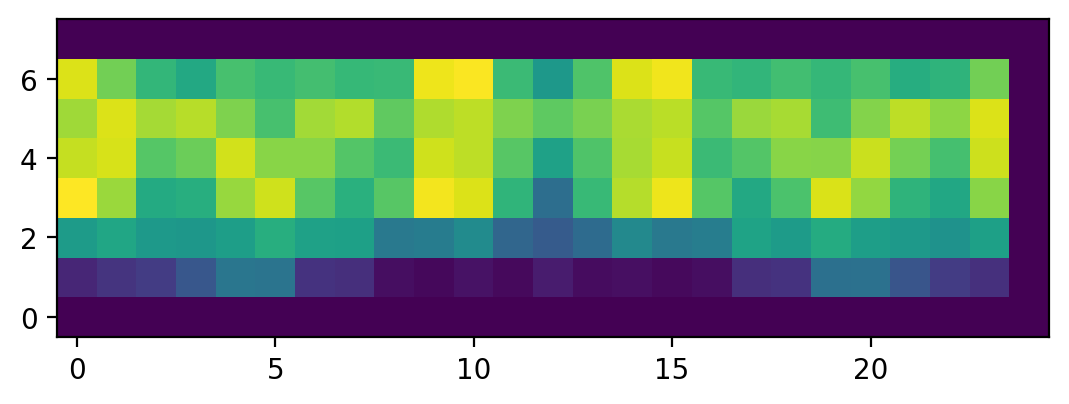

In [453]:
plt.imshow(ptr_imgs.sum(axis=0), origin='lower')

Text(0.5, 1.0, 'Average peak-to-trough values for all genes, N=5578')

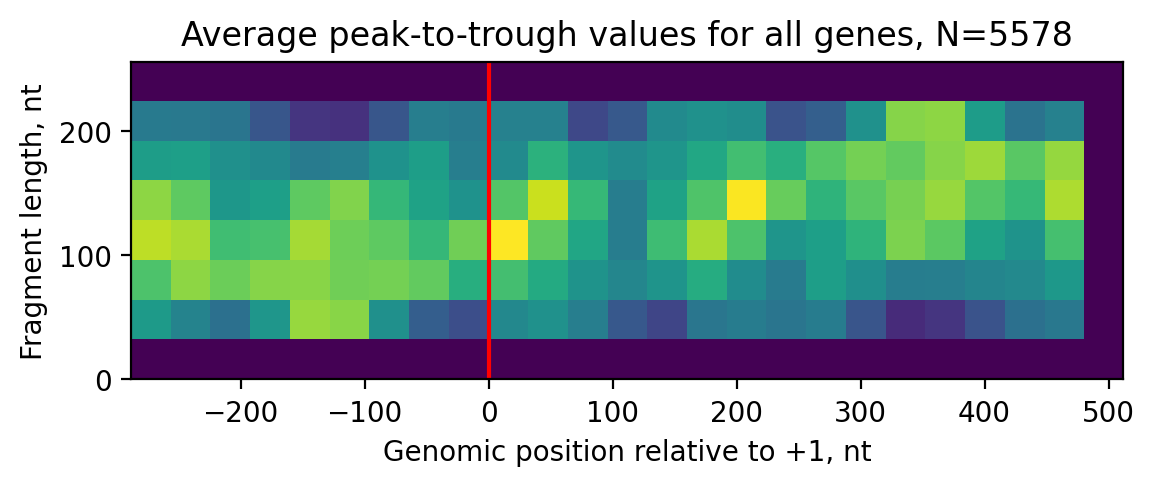

In [474]:
from cc_src.chromatin_metrics import yl_rep2_len_spans

plt.imshow(strand_corrected_ptr_imgs.sum(axis=0), origin='lower',
          extent=[-chromatin_model1.prom_len, chromatin_model1.gb_len,
                 0, chromatin_model1.max_y_len])

#chromatin_model1.bin_width, chromatin_model1.bin_height
#chromatin_model1.prom_len
#chromatin_model1.prom_len // chromatin_model1.bin_width
#chromatin_model1.gb_len // chromatin_model1.bin_width

smll, med, nuc_len = yl_rep2_len_spans()

#plt.axhline(smll[1], c='red')
plt.axvline(0, c='red')


#plt.axhline(nuc_len[0], c='red')
#plt.axhline(nuc_len[1], c='red')
#plt.axvline(0, c='red')
plt.xlabel("Genomic position relative to +1, nt")
plt.ylabel("Fragment length, nt")
plt.title(f"Average peak-to-trough values for all genes, N={len(ptr_imgs)}")

In [488]:
small_bins = 0, 100//chromatin_model1.bin_height
promoter_bins = 0, chromatin_model1.prom_len//chromatin_model1.bin_width

sm_frag_prom_imgs = strand_corrected_ptr_imgs[:, small_bins[0]:small_bins[1], 
    promoter_bins[0]:promoter_bins[1]]
sm_frag_prom_imgs.shape

(5578, 3, 9)

In [502]:
avg_sm_prom = sm_frag_prom_imgs.mean(axis=1).mean(axis=1)
avg_sm_ptrs = peak_to_trough_analysis.undropped_ptrs_df[[]].copy()
avg_sm_ptrs['mean_sm_prom_ptr'] = avg_sm_prom
avg_sm_ptrs['gene'] = peak_to_trough_analysis.geneset['gene']

avg_sm_ptrs.sort_values('mean_sm_prom_ptr', ascending=False)


,mean_sm_prom_ptr,gene
orf_name,,
YJL116C,2.233810,NCA3
YJR003C,2.144106,YJR003C
YLR050C,2.094904,YLR050C
YJL212C,2.088195,OPT1
YGL007C-A,2.087130,YGL007C-A
...,...,...
YMR170C,0.000011,ALD2
YJL138C,0.000011,TIF2
YOR246C,0.000000,YOR246C
